# Projek Data Science: Harga Properti di Brasil
## Pendahuluan
Proyek ini bertujuan untuk menganalisis data harga rumah di Brasil guna memahami faktor-faktor utama yang memengaruhi nilai properti, khususnya luas bangunan dan lokasi. Analisis dilakukan dengan pendekatan data sederhana agar dapat dipahami oleh pembaca umum, termasuk mereka yang tidak memiliki latar belakang teknis di bidang data.

Melalui proyek ini, diharapkan pembaca memperoleh gambaran dasar mengenai pola harga properti di Brasil serta bagaimana data dapat digunakan untuk menghasilkan insight yang relevan.

## Menyiapkan Alat Analisis
Pada tahap ini, beberapa pustaka Python digunakan untuk membantu proses analisis data:
1. Matplotlib untuk visualisasi data
2. Pandas untuk pengolahan dan manipulasi data
3. plotly.express untuk visualisasi data

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

## Memahami dan Menyiapkan Data
Dataset yang digunakan berisi informasi properti di Brasil, seperti:
1. lokasi (region dan state)
2. luas bangunan (area_m2)
3. harga rumah (price_usd)
4. koordinat geografis

Sebelum analisis dilakukan, data perlu diperiksa untuk memastikan konsistensi dan kelengkapan. Hal ini penting agar hasil analisis tidak menyesatkan.

### Data 1

In [48]:
df1 = pd.read_csv("C:\\Users\\Lenovo\\Documents\\Housing in Brazil\\brasil-real-estate-1.csv")
df1.shape
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12834 entries, 0 to 12833
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            12834 non-null  object 
 1   place_with_parent_names  12834 non-null  object 
 2   region                   12834 non-null  object 
 3   lat-lon                  11551 non-null  object 
 4   area_m2                  12834 non-null  float64
 5   price_usd                12834 non-null  object 
dtypes: float64(1), object(5)
memory usage: 601.7+ KB


,property_type,place_with_parent_names,region,lat-lon,area_m2,price_usd
0,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6443051,-35.7088142",110.0,"$187,230.85"
1,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.6430934,-35.70484",65.0,"$81,133.37"
2,house,|Brasil|Alagoas|Maceió|,Northeast,"-9.6227033,-35.7297953",211.0,"$154,465.45"
3,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.622837,-35.719556",99.0,"$146,013.20"
4,apartment,|Brasil|Alagoas|Maceió|,Northeast,"-9.654955,-35.700227",55.0,"$101,416.71"


### Data 2

In [49]:
df2 = pd.read_csv("C:\\Users\\Lenovo\\Documents\\Housing in Brazil\\brasil-real-estate-2.csv")
df2.shape
df2.info()
df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  12833 non-null  object 
 1   state          12833 non-null  object 
 2   region         12833 non-null  object 
 3   lat            12833 non-null  float64
 4   lon            12833 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_brl      12833 non-null  float64
dtypes: float64(4), object(3)
memory usage: 701.9+ KB


,property_type,state,region,lat,lon,area_m2,price_brl
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,414222.98
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,848408.53
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,299438.28
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,848408.53
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,464129.36


## Pembersihan Data
Data mentah sering kali mengandung nilai kosong (missing values) atau format yang tidak sesuai. Oleh karena itu, dilakukan beberapa langkah pembersihan data, antara lain:
1. Menghapus data yang tidak memiliki informasi penting
2. Memastikan tipe data numerik sudah benar
3. Memeriksa duplikasi atau anomali data

Tahap ini bertujuan untuk meningkatkan kualitas data sehingga analisis yang dihasilkan lebih dapat dipercaya.

### Pembersihan data 1

In [50]:
# Menghilangkan data null
df1.dropna(inplace=True)

# Mengubah Tipe Data Latitude dan Longitude Lalu Memisahkan Keduanya
df1[["lat", "lon"]] = df1["lat-lon"].str.split(",", expand=True).astype(float)

# Membuat Kolom "state" dari Kolom "place_with_parent_names"
df1["state"] = df1["place_with_parent_names"].str.split("|", expand=True)[2]

# Membersihkan kolom "price_usd" dan mengubahnya ke tipe data float
df1["price_usd"] = df1["price_usd"].str.replace("$", "").str.replace(",", "").astype(float)

# Menghilangkan Kolom "lat-lon" dan "place_with_parent_names"
df1.drop(columns=["lat-lon", "place_with_parent_names"], inplace=True)

df1.shape
df1.info()
df1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 11551 entries, 0 to 12833
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11551 non-null  object 
 1   region         11551 non-null  object 
 2   area_m2        11551 non-null  float64
 3   price_usd      11551 non-null  float64
 4   lat            11551 non-null  float64
 5   lon            11551 non-null  float64
 6   state          11551 non-null  object 
dtypes: float64(4), object(3)
memory usage: 721.9+ KB


,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


### Pembersihan data 2

In [51]:
# Menghilangkan nilai null
df2.dropna(inplace=True)

# Mengubah mata uang ke usd
df2["price_usd"] = (df2["price_brl"] / 3.19).round(2)

# Menghilangkan kolom "price_brl"
df2.drop(columns="price_brl", inplace=True)

df2.shape
df2.info()
df2.head()

<class 'pandas.core.frame.DataFrame'>
Index: 11293 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  11293 non-null  object 
 1   state          11293 non-null  object 
 2   region         11293 non-null  object 
 3   lat            11293 non-null  float64
 4   lon            11293 non-null  float64
 5   area_m2        11293 non-null  float64
 6   price_usd      11293 non-null  float64
dtypes: float64(4), object(3)
memory usage: 705.8+ KB


,property_type,state,region,lat,lon,area_m2,price_usd
0,apartment,Pernambuco,Northeast,-8.134204,-34.906326,72.0,129850.46
1,apartment,Pernambuco,Northeast,-8.126664,-34.903924,136.0,265958.79
2,apartment,Pernambuco,Northeast,-8.125550,-34.907601,75.0,93867.80
3,apartment,Pernambuco,Northeast,-8.120249,-34.895920,187.0,265958.79
4,apartment,Pernambuco,Northeast,-8.142666,-34.906906,80.0,145495.10


## Menyatukan Data 1 dan Data 2

In [52]:
df = pd.concat([df1, df2])
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 22844 entries, 0 to 12832
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  22844 non-null  object 
 1   region         22844 non-null  object 
 2   area_m2        22844 non-null  float64
 3   price_usd      22844 non-null  float64
 4   lat            22844 non-null  float64
 5   lon            22844 non-null  float64
 6   state          22844 non-null  object 
dtypes: float64(4), object(3)
memory usage: 1.4+ MB


,property_type,region,area_m2,price_usd,lat,lon,state
0,apartment,Northeast,110.0,187230.85,-9.644305,-35.708814,Alagoas
1,apartment,Northeast,65.0,81133.37,-9.643093,-35.704840,Alagoas
2,house,Northeast,211.0,154465.45,-9.622703,-35.729795,Alagoas
3,apartment,Northeast,99.0,146013.20,-9.622837,-35.719556,Alagoas
4,apartment,Northeast,55.0,101416.71,-9.654955,-35.700227,Alagoas


## Analisis Data

In [53]:
fig = px.scatter_map(
    df,
    lat="lat",
    lon="lon",
    center={"lat": -14.2, "lon": -51.9},
    width=600,
    height=600,
    hover_data=["price_usd"],
)
fig.update_layout(mapbox_style="open-street-map")

fig.show()

In [54]:
summary_stats = df[["area_m2", "price_usd"]].describe()
summary_stats

,area_m2,price_usd
count,22844.000000,22844.000000
mean,115.020224,194987.315515
std,47.742932,103617.682979
min,53.000000,74892.340000
25%,76.000000,113898.770000
50%,103.000000,165697.555000
75%,142.000000,246900.882500
max,252.000000,525659.720000


Text(0.5, 1.0, 'Distribusi Harga Rumah')

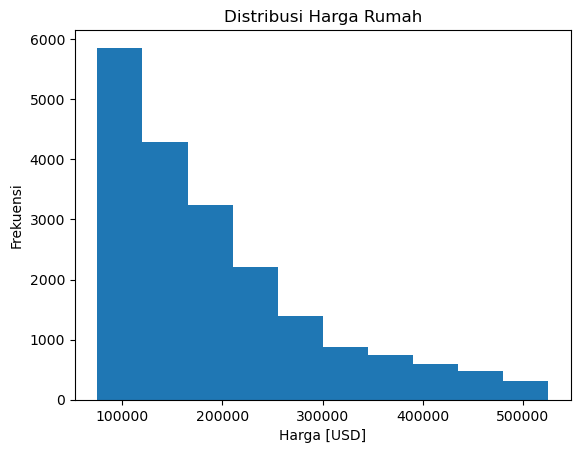

In [55]:
plt.hist(df["price_usd"].head(20000))
plt.xlabel("Harga [USD]")
plt.ylabel("Frekuensi")
plt.title("Distribusi Harga Rumah")

Text(0.5, 1.0, 'Distribusi Luas Rumah')

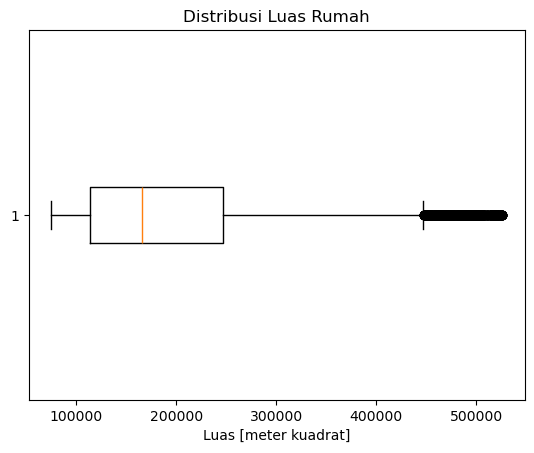

In [56]:
plt.boxplot(df["price_usd"], vert=False)
plt.xlabel("Luas [meter kuadrat]")
plt.title("Distribusi Luas Rumah")

In [57]:
mean_price_by_region = df.groupby("state")["price_usd"].mean().sort_values()
mean_price_by_region

state
Tocantins               90738.870000
Rondônia               111403.616000
Mato Grosso do Sul     127473.475000
Sergipe                142418.029559
Amapá                  148349.220000
Amazonas               148744.510000
Espírito Santo         149688.857730
Piauí                  154192.247917
Paraíba                157509.767960
Rio Grande do Norte    161747.307483
Mato Grosso            163711.913953
Paraná                 164168.840031
Maranhão               167956.091683
Goiás                  171347.391982
Rio Grande do Sul      174498.180670
Alagoas                180356.561250
Bahia                  183215.884689
Pará                   183217.820669
Distrito Federal       186818.838306
Ceará                  192614.281423
Minas Gerais           200534.601071
São Paulo              213903.560813
Pernambuco             217153.048547
Rio de Janeiro         225106.537551
Santa Catarina         227570.741272
Name: price_usd, dtype: float64

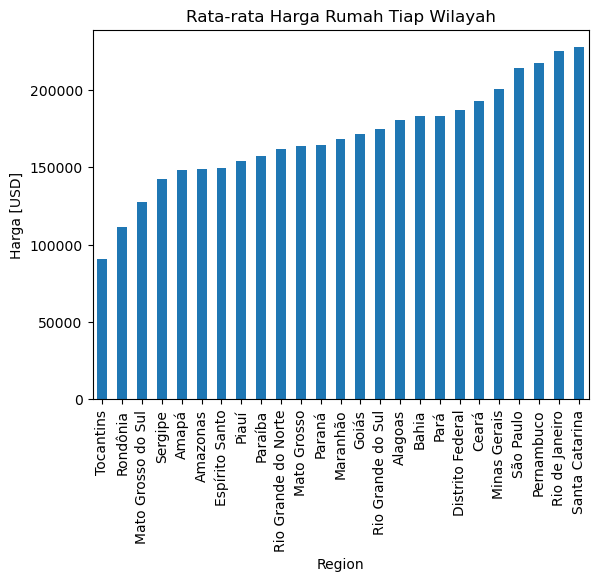

In [58]:
mean_price_by_region.plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Harga [USD]")
plt.title("Rata-rata Harga Rumah Tiap Wilayah")
plt.show()

## Fokus Analisis: Wilayah Selatan Brasil
Analisis selanjutnya difokuskan pada wilayah South (Selatan) Brasil
1. Paraná
2. Santa Catarina
3. Rio Grande do Sul

In [59]:
df_south = df[df["region"] == "South"]
df_south.head()

,property_type,region,area_m2,price_usd,lat,lon,state
9304,apartment,South,127.0,296448.85,-25.455704,-49.292918,Paraná
9305,apartment,South,104.0,219996.25,-25.455704,-49.292918,Paraná
9306,apartment,South,100.0,194210.50,-25.460236,-49.293812,Paraná
9307,apartment,South,77.0,149252.94,-25.460236,-49.293812,Paraná
9308,apartment,South,73.0,144167.75,-25.460236,-49.293812,Paraná


In [60]:
homes_by_state = df_south["state"].value_counts()
homes_by_state

state
Rio Grande do Sul    2643
Santa Catarina       2634
Paraná               2544
Name: count, dtype: int64

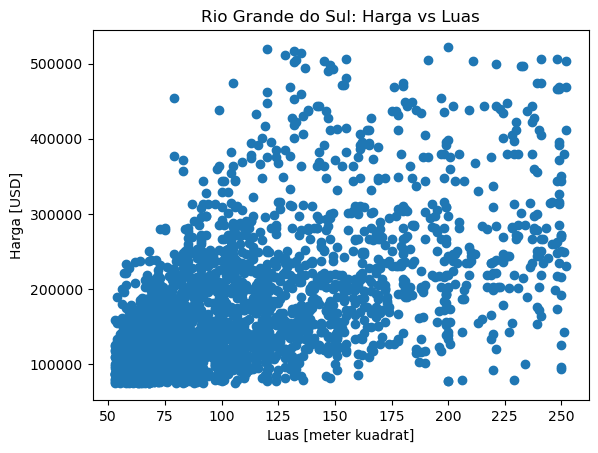

In [61]:
df_south_rgs = df_south[df_south["state"] == "Rio Grande do Sul"]

plt.scatter(x=df_south_rgs["area_m2"], y=df_south_rgs["price_usd"])
plt.xlabel("Luas [meter kuadrat]")
plt.ylabel("Harga [USD]")
plt.title("Rio Grande do Sul: Harga vs Luas")
plt.show()

## Hubungan Luas Bangunan dan Harga Rumah
Untuk memahami hubungan antara luas bangunan dan harga rumah, digunakan korelasi Pearson. Nilai korelasi berada pada rentang -1 hingga 1:
1. Nilai mendekati 1 menunjukkan hubungan positif yang kuat
2. Nilai mendekati 0 menunjukkan hubungan yang lemah
3. Nilai mendekati -1 menunjukkan hubungan negatif

Hasil perhitungan korelasi menunjukkan bahwa ketiga state di wilayah Selatan memiliki korelasi positif sedang. Artinya, secara umum rumah dengan luas bangunan yang lebih besar cenderung memiliki harga yang lebih tinggi, meskipun faktor lain seperti lokasi spesifik dan kondisi lingkungan tetap berperan.

In [62]:
south_states_corr = {}

south_states = df_south["state"].unique()

for state in south_states:
    subset = df_south[df_south["state"] == state]
    corr = subset["area_m2"].corr(subset["price_usd"])
    south_states_corr[state] = float(corr)

south_states_corr


{'Paraná': 0.5436659935502658,
 'Rio Grande do Sul': 0.5773267433871906,
 'Santa Catarina': 0.5068121769989852}

## Interpretasi Hasil
Beberapa insight yang dapat diambil dari analisis ini:
1. Luas bangunan merupakan faktor penting dalam menentukan harga rumah.
2. Setiap state memiliki karakteristik pasar properti yang berbeda.
3. Korelasi yang tidak terlalu tinggi menunjukkan bahwa harga rumah tidak hanya ditentukan oleh luas bangunan saja.

Insight ini dapat menjadi dasar untuk analisis lanjutan, misalnya dengan menambahkan variabel lain seperti jumlah kamar atau jarak ke pusat kota.

## Kesimpulan
Berdasarkan analisis yang dilakukan, dapat disimpulkan bahwa:
1. Luas bangunan memiliki hubungan positif dengan harga rumah di wilayah Selatan Brasil, dengan tingkat kekuatan yang sedang.
2. Pendekatan analisis data yang beragam dapat meningkatkan kualitas insight yang dihasilkan.

Secara keseluruhan, proyek ini menunjukkan bagaimana data properti dapat dianalisis secara sederhana namun bermakna, sehingga mudah dipahami oleh pembaca umum dan relevan sebagai portofolio analisis data.